


Вариант А. Сорта подсолнечника по регионам допуска.

https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%B4%D1%81%D0%BE%D0%BB%D0%BD%D0%B5%D1%87%D0%BD%D0%B8%D0%BA

(Таблица связи сортов подсолнечника и регионов допуска).




# Часть 1. Скачай данные из табличек + информацию о географических данных (широта и долгота) + подчисти датасет. 3 балла.

Я называю регионы допуска округами, под регионами понимаются регионы РФ.

In [ ]:
import urllib, requests, socket, re, lxml, io, bs4, sqlite3, pandas, sqlalchemy
from requests.compat import urljoin, urlparse, unquote
from bs4 import BeautifulSoup
import re
import pandas as pd

url = "https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%B4%D1%81%D0%BE%D0%BB%D0%BD%D0%B5%D1%87%D0%BD%D0%B8%D0%BA"

html = requests.get(url).text

soup = BeautifulSoup(html, "html.parser")
hrefs = soup.findAll('a')
links = [urljoin(url, link.get('href')) for link in hrefs ]

def filter_1(listik, keywords=['Регионы', "https://ru.wikipedia.org/wiki/"]):
  filtered_link=[]
  for link in links:
    link_1=unquote(link)
    if all([keyword in link_1 for keyword in keywords]):
       filtered_link.append(link)
  return filtered_link
filtered_link = filter_1(links)

text =( soup.get_text(separator="\n", strip=True) ).split('\n')
def filter_2(listik, keyword='Гибрид'):
  filtered_words=[]
  for word in listik:
    if keyword in word:
      filtered_words.append(" ".join(word.split()[1:]))
  return filtered_words
species_names = filter_2(text)

text_1 =( soup.get_text(separator="\n", strip=True) ).split('\n')
def filter_3(listik):
  filtered_regions=[]
  for i in range(len(listik)-1):
    if "урожайность" in listik[i+1]:
      try:
        numbers = [int(a) for a in listik[i].split(", ")]
        filtered_regions.append(numbers)
      except Exception as e:
        pass
  return filtered_regions
filtered_regions = filter_3(text_1)

reg_hybrids={}
for i in range(1, 13):
  list_of_gybrids=[]
  for j in range(10):
    if i in filtered_regions[j]:
      list_of_gybrids.append(species_names[j])
  reg_hybrids[str(i)]=list_of_gybrids
print(reg_hybrids)

url_1=filtered_link[0]
html_1 = requests.get(filtered_link[0]).content.decode('utf-8')
soup_1 = BeautifulSoup(html_1, "html.parser")
hrefs_1 = soup_1.findAll('a')
links_1 = [urljoin(url_1, link.get('href')) for link in hrefs_1 ]

def filter_regions(listik, keyword="https://ru.wikipedia.org/wiki/", add_keywords=['область', 'край', 'Республика']):
  filtered_link=[]
  for link in links_1:
    link_1=unquote(link)
    if keyword in link_1 and any([key in link_1 for key in add_keywords]):
       filtered_link.append(link_1)
  return filtered_link
filtered_reg_links = filter_regions(links_1)
text_1 =( soup_1.get_text(separator="\n", strip=True) ).split("\n")

ocr_regions={}
add_keywords=['область', 'край', 'Республика']
key_now = "Северный"
for i in range(len(text_1)-2):
  if any(a in text_1[i] for a in add_keywords):
    ocr_regions[key_now].append(text_1[i])
  elif text_1[i-1]!= "Хабаровский край" and any(a in text_1[i+2] for a in add_keywords):
    key_now =  text_1[i]
    ocr_regions[key_now]=[]

ocr_number ={}
for i in range(12):
  ocr_number[list(ocr_regions.keys())[i]]=str(i+1)
#print(ocr_number)

region_coordinates={}
pattern = r'"lat":\s*(-?\d+\.?\d*),\s*"lon":\s*(-?\d+\.?\d*)'
for link in filtered_reg_links:
  url=link
  html = requests.get(link).content.decode('utf-8')
  soup = BeautifulSoup(html, "html.parser")
  script_tag = soup.find('script', string=re.compile(r'wgCoordinates'))
  text = script_tag.get_text()
  match = re.search(pattern, text)
  if match:
    lat = float(match.group(1))
    lon = float(match.group(2))
    region_coordinates[" ".join(link[30:].split("_"))] = [lat, lon]

main_dict={}
for link in filtered_reg_links:
  name = " ".join(link[30:].split("_"))
  for key, value in ocr_regions.items():
    if name in value:
      main_dict[name]=[key, ocr_number[key],  reg_hybrids[ocr_number[key]], region_coordinates[name]]

main_data = pd.DataFrame(main_dict)
main_data_1=pd.DataFrame(main_dict)
main_data_2=pd.DataFrame(main_dict)
main_data_3=pd.DataFrame(main_dict)
#main_data

<ipython-input-1-5cec07704fa5>:12: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  hrefs = soup.findAll('a')


{'1': [], '2': [], '3': [], '4': [], '5': ['НК Неома', 'П 63 ЛЕ 10', 'Сумико', 'Енисей'], '6': ['НК Неома', 'П 64 ЛЕ 25', 'Енисей', 'ЛГ 59580', 'ПР 64 Ф 66'], '7': ['НК Неома', 'Енисей', 'НК Фортими', 'ЕС Генезис', 'Сузука'], '8': ['НК Фортими', 'ЕС Генезис'], '9': ['Енисей'], '10': ['Енисей'], '11': ['Енисей'], '12': []}


<ipython-input-1-5cec07704fa5>:58: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  hrefs_1 = soup_1.findAll('a')


# Часть 2. Визуализируй графики без учёта карт/координат (либо по годам, либо barplot - по категориям) - 2 балла.

Нужно сделать не менее 3 различных **информативных** графиков с учётом данных из части 1.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

graph_1=main_data_1
graph_1.iloc[2] = main_data_1.iloc[2].apply(lambda x: len(x))
graph_1= graph_1.iloc[1:3, :]

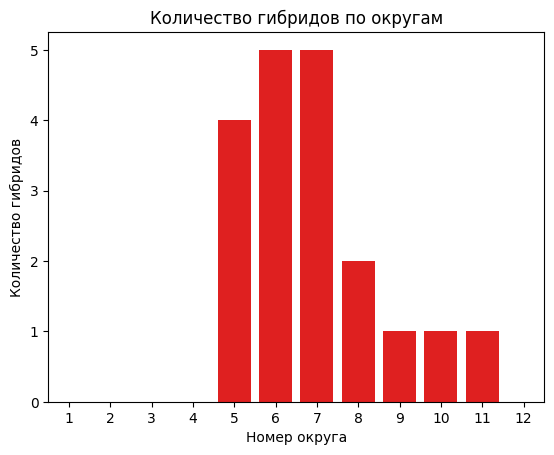

In [ ]:
row1 = graph_1.iloc[0]
row2 = graph_1.iloc[1]

graph_11 = pd.DataFrame([row1, row2], index=['Row 1', 'Row 2'])

graph_11 = graph_1.T.reset_index()
graph_11.columns = ['Регион', 'Номер округа', 'Количество гибридов']

sns.barplot(x='Номер округа', y='Количество гибридов', data=graph_11, color='red')

plt.xlabel('Номер округа')
plt.ylabel('Количество гибридов')
plt.title('Количество гибридов по округам')
plt.show()

In [ ]:
graph_4 = main_data_2.iloc[1:3, :]
graph_4.iloc[1] = main_data_2.iloc[2].apply(lambda x: len(x))
#main_data_2


<ipython-input-4-a86d9b2c9f58>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graph_4.iloc[1] = main_data_2.iloc[2].apply(lambda x: len(x))


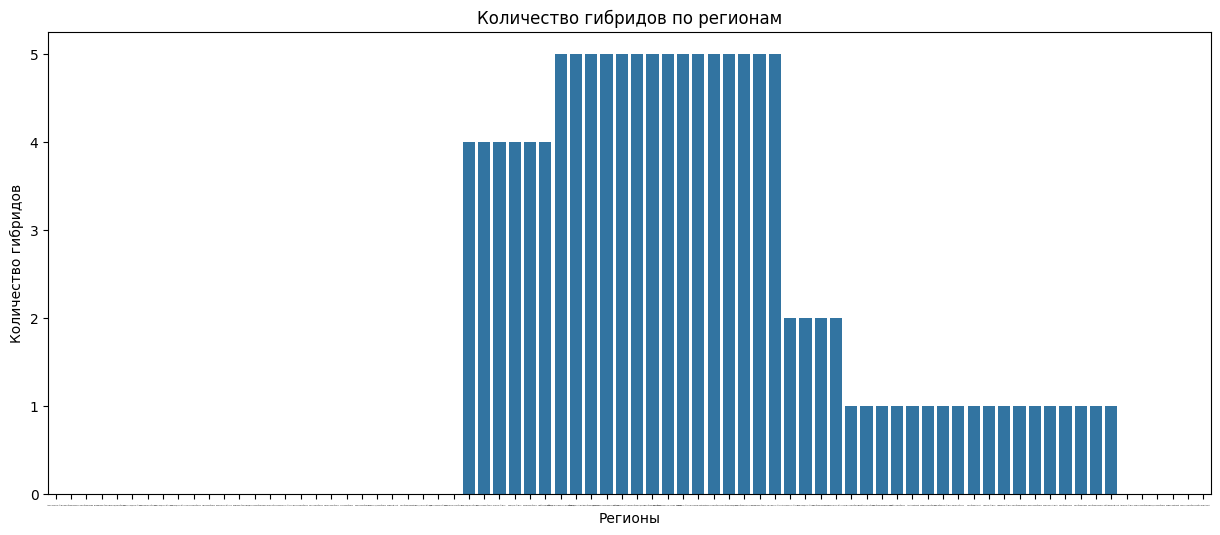

In [ ]:
columns = graph_4.columns
values = graph_4.iloc[1, :]
plt.figure(figsize=(15, 6))

plot_data = pd.DataFrame([columns, values])
plot_data = plot_data.T.reset_index()
plot_data.columns = ['Регион1', 'Регионы', "Количество гибридов"]

sns.barplot(x='Регионы', y='Количество гибридов', data=plot_data)

plt.title('Количество гибридов по регионам')
plt.xticks(fontsize=1)

plt.show()



In [ ]:
graph=main_data_3.iloc[1:2, :]
dict_1={}
for i in range(1, 13):
  count = (graph == str(i)).sum().sum()
  dict_1[str(i)]= [i, count]
graph_2 = pd.DataFrame.from_dict(dict_1)


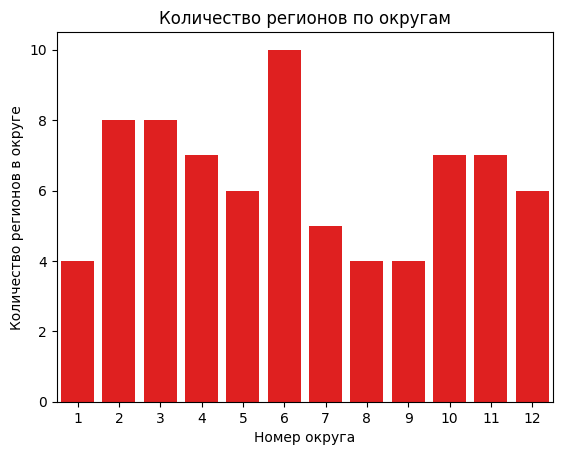

In [ ]:
row1 = graph_2.iloc[0]
row2 = graph_2.iloc[1]

graph_22 = pd.DataFrame([row1, row2], index=['Row 1', 'Row 2'])

graph_22 = graph_2.T.reset_index()
graph_22.columns = ['Номер округа', 'Номер округа_1', 'Количество регионов в нем']

sns.barplot(x='Номер округа', y='Количество регионов в нем', data=graph_22, color='red')

plt.xlabel('Номер округа')
plt.ylabel('Количество регионов в округе')
plt.title('Количество регионов по округам')
plt.show()

In [ ]:
graph_3= main_data_3.iloc[2, :]
gybrid_number_of_regions={}
for gybrid in species_names:
  count=0
  for i in range(len(graph_3)):
    if gybrid in graph_3.iloc[i]:
      count+=1
  gybrid_number_of_regions[gybrid]=[gybrid, count]
graph_3=pd.DataFrame(gybrid_number_of_regions)

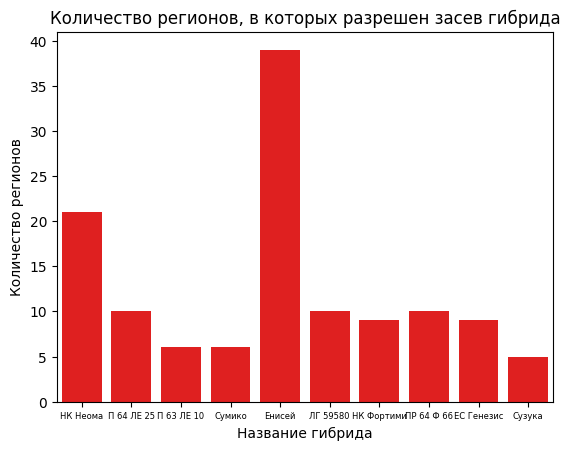

In [ ]:
row1 = graph_3.iloc[0]
row2 = graph_3.iloc[1]

graph_33 = pd.DataFrame([row1, row2], index=['Row 1', 'Row 2'])

graph_33 = graph_33.T.reset_index()
graph_33.columns = ['Название гибрида_1', 'Название гибрида', "Количество регионов"]

sns.barplot(x='Название гибрида', y='Количество регионов', data=graph_33, color='red')

plt.xlabel('Название гибрида')
plt.ylabel('Количество регионов')
plt.title('Количество регионов, в которых разрешен засев гибрида')
plt.xticks(fontsize=6)
plt.show()

Из данных графиков можно сделать следующие выводы:

1) Количество гибридов по округам

На этом графике мы можем видеть, что наибольшее число гибридов разрешено к посеву в округах 6 и 7. Значит, округа Северо-Кавказский и Средневолжский имеют наиболее универсальные условия для выращивания подсолнечника.

2) Количество гибридов по регионам

На этом графике можно видеть области, в которых к посеву допущено наибольшее число сортов подсолнечника. Значит, данные области имеют наиболее универсальные погодные условия для выращивания данной культуры.

3) Количество регионов в округах(регионах допуска)

Регионы РФ объединены в регионы допуска по схожести агропромышленных условий. Значит, наиболее большая группа регионов со схожим климатом - округ 6, Северо-Кавказский.

4) Количество регионов, в которых разрешен засев гибрида

Из графика видим, что наиболее распространенный гибрид, разрешаенный для засева - гибрид "Енисей" - он разрешен к засеву в 40 регионах РФ. Можно сделать вывод, что этот сорт подсолнечника самый неприхотливый.



# Часть 3. Визуализируй графики на картах при помощи plotly - 3 балла.

In [ ]:
row2 = main_data.iloc[3]
row1 = main_data.columns
df_coords = pd.DataFrame([row1, row2], index=['Регионы', 'Координаты']).T

columns = graph_4.columns
values = graph_4.iloc[1, :]
df_amounts = pd.DataFrame([columns, values], index=['Регионы', 'Количество гибридов']).T

In [ ]:
import plotly.express as px

df = pd.merge(df_coords, df_amounts, on='Регионы')

df["Широта"] = df["Координаты"].apply(lambda x: float(x[0]))

df["Долгота"]=df["Координаты"].apply(lambda x: float(x[1]))

df['Количество гибридов'] = df['Количество гибридов'].apply(lambda x: int(x))

fig = px.scatter_geo(
    df,
    lat='Широта',
    lon='Долгота',
    size='Количество гибридов',
    hover_name='Регионы',
    projection='natural earth',
    title='Количество гибридов по регионам',
    color='Количество гибридов',
    color_continuous_scale=px.colors.sequential.Plasma  )


fig.update_geos(
    showcountries=True,
    showland=True,
    landcolor='lightgray'
)


fig.update_traces(marker=dict(sizemode='area', sizeref=0.1))

fig.show()
#df

,Регионы,Координаты,Количество гибридов,Широта,Долгота
0,Архангельская область,"[63.5, 43.0]",0,63.500000,43.000000
1,Республика Карелия,"[63.816666666667, 33.0]",0,63.816667,33.000000
2,Республика Коми,"[64.283333333333, 54.466666666667]",0,64.283333,54.466667
3,Мурманская область,"[68.033333333333, 34.566666666667]",0,68.033333,34.566667
4,Вологодская область,"[60.083333333333, 40.45]",0,60.083333,40.450000
...,...,...,...,...,...
71,Камчатская область,"[55.0, 159.0]",0,55.000000,159.000000
72,Магаданская область,"[62.9, 153.7]",0,62.900000,153.700000
73,Приморский край,"[45.333333333333, 134.66666666667]",0,45.333333,134.666667
74,Сахалинская область,"[50.55, 142.6]",0,50.550000,142.600000


<font color="violet"> Какие выводы можно сделать из этих графиков? </font>

По данному графику можно сделать вывод, что наиболее привлекательные климатические условия для выращивания различных видов подсолнечника имеют регионы, обозначенные желтым на карте. Также видно, что регионы с наибольшими показателями количества допущенных к посеву гибридов сосредоточены на юго-западе России.

Остальные графики, которые я делала в предыдущем пункте, не подходят для визуализации на карте, потому что в них отоображается либо связь гибридов и округов, либо связь округов и регионов, а округа это всего лишь более крупные объедиения регионов. Графики на картах, которые отражают эти взаимосвязи, не будут информативными.

# Часть 4. Получи данные о текущей погоде в этих географических точках при помощи Яндекс API - 4 балла.

In [ ]:
import requests

access_key = ""

headers = {
    "X-Yandex-Weather-Key": access_key
}

df['Температура']=0
df['Осадки']=0
df['Давление']=0
def get_weather(lat, lon):
    url = f'https://api.weather.yandex.ru/v2/forecast?lat={lat}&lon={lon}'
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json().get('fact', {})
for i in range(76):
  df.iloc[i, 5] = get_weather(df.iloc[i, 3], df.iloc[i, 4])['temp']
  df.iloc[i, 6] = get_weather(df.iloc[i, 3], df.iloc[i, 4])['prec_strength']
  df.iloc[i, 7] = get_weather(df.iloc[i, 3], df.iloc[i, 4])['pressure_mm']
df_1=df

<ipython-input-12-f8da10dd5079>:19: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



# Часть 5. Визуализируй данные о погоде на картах при помощи plotly - 3 балла.

In [ ]:
fig_1 = px.scatter_geo(
    df_1,
    lat='Широта',
    lon='Долгота',
    hover_name='Регионы',
    projection='natural earth',
    title='Температура в регионах',
    color='Температура',
    color_continuous_scale=px.colors.sequential.Plasma  )
fig_1.update_geos(
    showcountries=True,
    showland=True,
    landcolor='lightgray'
)

fig_1.update_traces(marker=dict(sizemode='area', sizeref=0.1))
fig_1.show()


fig_2 = px.scatter_geo(
    df_1,
    lat='Широта',
    lon='Долгота',
    hover_name='Регионы',
    projection='natural earth',
    title='Осадки в регионах',
    size='Осадки',
    color_continuous_scale=px.colors.sequential.Plasma  )
fig_2.update_geos(
    showcountries=True,
    showland=True,
    landcolor='lightgray'
)

fig_2.update_traces(marker=dict(sizemode='area', sizeref=0.1))
fig_2.show()


fig_3 = px.scatter_geo(
    df_1,
    lat='Широта',
    lon='Долгота',
    hover_name='Регионы',
    projection='natural earth',
    title='Атмосферное давление в регионах',
    color='Давление',
    color_continuous_scale=px.colors.sequential.Plasma  )
fig_3.update_geos(
    showcountries=True,
    showland=True,
    landcolor='lightgray'
)

fig_3.update_traces(marker=dict(sizemode='area', sizeref=0.1))
fig_3.show()